In [1]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00


# Merge the Dataset Files


---






In [2]:

import pandas as pd
import os
# Mount Google Drive where the files of data exist
from google.colab import drive
drive.mount('/content/drive')


def load_and_merge_files(folder_path):
  """
  Load all CSV files from a folder and merge them
  into a single DataFrame.

  Parameters:
  - folder_path: Path to the folder containing the CSV files.
  """

  # List to store the data
  all_dfs = []

  # Read each CSV file in the folder
  for filename in os.listdir(folder_path):
      if filename.endswith('.csv'):
          file_path = os.path.join(folder_path, filename)
          df = pd.read_csv(file_path)
          all_dfs.append(df)

  # Combine all the data into a single DataFrame
  df = pd.concat(all_dfs, ignore_index=True)

  # Display basic information about the data which number of rows and columns
  print("Dataset shape:", df.shape)

  return df








# Calling of function, with the path of the data which exist in google drive
df = load_and_merge_files("/content/drive/My Drive/Several-datasets/Data_1")



Mounted at /content/drive
Dataset shape: (3384189, 85)


In [3]:

def basic_Information(df):
  '''
  Showing basic information about the dataset.

  Parameters:
  - df: DataFrame containing the dataset.
  '''

  # Print the count of each class.
  print('The count of each class :\n\n',df['Attack Name'].value_counts())
  print('\n\n\n\n\n\n\n')


  # Show the first five rows of the dataset for an initial inspection
  print('The first five rows of the dataset :\n\n')
  df.head()
  print('\n\n\n\n\n\n\n')


  # Basic statistics
  print('Basic statistics about the dataset: \n\n')
  df.describe()
  print('\n\n\n\n\n\n\n')


  # Print type of each columns
  print('Print type of each columns: \n\n')
  df.info()
  print('\n\n\n\n\n\n\n')







# Caliing for showing basic information about the dataset
basic_Information(df)



The count of each class :

 Attack Name
DoS TCP Flood               2106916
Recon Port Scan              485522
MQTT DDoS Publish Flood      413913
MQTT DoS Connect Flood       238031
Recon OS Scan                 85317
Benign Traffic                32620
Recon Vulnerability Scan       8321
DoS UDP Flood                  3115
DDoS UDP Flood                 2576
DDoS ICMP Flood                2552
MQTT Malformed                 2246
DoS ICMP Flood                 2107
MQTT DoS Publish Flood          953
Name: count, dtype: int64








The first five rows of the dataset :










Basic statistics about the dataset: 










Print type of each columns: 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3384189 entries, 0 to 3384188
Data columns (total 85 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Flow ID                     object 
 1   Src IP                      object 
 2   Src Port                    int64  
 3   Dst IP    

# Preprocessing



---



In [4]:

def check_dataset(df):
  '''
  Prepare dataset for machine learning by check the
  values of dataset and columns

  Parameters:
  - df: DataFrame containing the dataset.
  '''

  # Variable to save name of target column
  label_column = "Attack Name"

  # Non-numeric columns which I will remove it.
  non_numeric_columns = df.select_dtypes(exclude=['number']).columns.drop(label_column)

  # Drop the columns.
  df.drop(columns=non_numeric_columns, inplace=True)

  # Display Names of the removed columns.
  print("Names of the removed columns:", non_numeric_columns.to_list(),'\n\n\n\n')

  # Shape of data, number of columns and rows.
  print("\nShape of dataset after deleting: ", df.shape,'\n\n\n\n')




  # Count the number of missing values (NaN) in each column
  missing_values = df.isnull().sum()

  # Keep only columns that contain one or more missing values,
  # then sort them from the highest number of missing values to the lowest
  missing_report = missing_values[missing_values > 0].sort_values(ascending=False).to_list()

  # Print the columns that contain missing values
  print('\nthe columns that contain missing values : ',missing_report ,'\n\n\n\n')




  # Check for duplicate columns in numeric data
  duplicate_columns_numeric = df.columns[df.columns.duplicated()].to_list()

  # Print the list of duplicate columns in numeric data (if any)
  print(f"\nDuplicate columns in numeric data: {duplicate_columns_numeric}",'\n\n\n')







# Calling function for check the values of dataset and columns
check_dataset(df)


Names of the removed columns: ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp'] 





Shape of dataset after deleting:  (3384189, 81) 





the columns that contain missing values :  [] 





Duplicate columns in numeric data: [] 





# Grouping Data and Taking Samples


---



In [5]:


def grouping_attacks(df):
  '''
   Grouping the same type of attacks togother. and taking samples from classes.

  Parameters:
  - df: DataFrame containing the dataset.
  '''

  df['Attack Name'] = df['Attack Name'].replace({

      'DoS TCP Flood':'DoS Flood' ,'DoS ICMP Flood':'DoS Flood', 'DoS UDP Flood':'DoS Flood' ,

      'DDoS ICMP Flood':'DDoS Flood', 'DDoS UDP Flood':'DDoS Flood',

      'Recon OS Scan': 'Recon Flood' ,'Recon Port Scan': 'Recon Flood' , 'Recon Vulnerability Scan': 'Recon Flood' ,

      'MQTT DDoS Publish Flood': 'MQTT Flood', 'MQTT DoS Connect Flood':'MQTT Flood' , 'MQTT Malformed':'MQTT Flood', 'MQTT DoS Publish Flood':'MQTT Flood'

      })

  # Print the count of each class after grouping.
  print('\n\n',df['Attack Name'].value_counts(),'\n\n\n\n\n\n')





  # The target attack types
  class_names = ['DoS Flood', 'DDoS Flood', 'Recon Flood', 'MQTT Flood']

  # Maximum number of samples per type.
  sample_size = 20000

  # Sample records (Attack traffic) without duplication.
  Sample1 = pd.concat([
      df[df['Attack Name'] == attack_type].sample(
          n=min(sample_size, len(df[df['Attack Name'] == attack_type])),
          random_state=42,
          replace=False
      )
      for attack_type in class_names
  ])


  # Sample records (normal traffic) without duplication.
  Sample2 = pd.concat([
      df[df['Attack Name'] == 'Benign Traffic'].sample(
          n=min(32620, len(df[df['Attack Name'] == 'Benign Traffic'])),
          random_state=42,
          replace=False
      )
  ])

  # Combine two traffics type togother.
  sample_Data = pd.concat([Sample1, Sample2], ignore_index=True)

  # Display the number of samples taken from each type.
  print(sample_Data['Attack Name'].value_counts(),'\n\n\n')


  return sample_Data







# Calling for grouping attacks and taking sampels from classes
sample_Data = grouping_attacks(df)





 Attack Name
DoS Flood         2112138
MQTT Flood         655143
Recon Flood        579160
Benign Traffic      32620
DDoS Flood           5128
Name: count, dtype: int64 






Attack Name
Benign Traffic    32620
DoS Flood         20000
Recon Flood       20000
MQTT Flood        20000
DDoS Flood         5128
Name: count, dtype: int64 





# Several Functions for Systems

---



In [6]:

from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import  VotingClassifier ,RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectFromModel, VarianceThreshold
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from collections import Counter
import lightgbm as lgb
import time
import numpy as np
import seaborn as sns





def create_feature_selector():
  """
  Create a Random Forest-based feature selector. Features with importance greater than the mean
  importance are retained.
  """

  # Select important features using a Random Forest model.
  # Only features with importance greater than the mean importance are kept.
  rf_selector = SelectFromModel(
      RandomForestClassifier(
          n_estimators=100,
          random_state=42
      ),
      threshold="mean"
  ).set_output(transform="pandas")


  return rf_selector







def plot_confusion_matrix_single(model, X_test, y_test, class_names=None, title="Confusion Matrix"):
  """
  Plot confusion matrix for a single classification model.

  Parameters:
  - model: Trained classification model.
  - X_test: Test data features.
  - y_test: True labels.
  - class_names: List of class labels (optional).
  - title: Title of the plot.
  """

  # Predict using the pipeline model
  y_pred = model.predict(X_test)

  # Compute the confusion matrix
  cm = confusion_matrix(y_test, y_pred)

  # Plot the confusion matrix
  disp = ConfusionMatrixDisplay( confusion_matrix=cm , display_labels= class_names )
  disp.plot(cmap='Greens', values_format='d')
  plt.title(title)
  plt.tight_layout()
  print("\n\n\n")
  plt.show()
  print("\n\n\n")






def plot_confusion_matrix_voting(model, model_name, X_test, y_test, class_names, lab, title="Confusion Matrix"):
  """
  Plot a single confusion matrix for a pipeline-based voting model.

  Parameters:
  - model: Trained pipeline model with a voting classifier.
  - model_name: Name of the model for labeling the plot.
  - X_test: Test data features.
  - y_test: True labels.
  - class_names: List of class labels for the confusion matrix display.
  - lab: List of labels for the confusion matrix display.
  - title: Title for the confusion matrix plot.
  """

  # Predict using the pipeline model
  y_pred = model.predict(X_test)

  # Compute the confusion matrix
  cm = confusion_matrix(y_test, y_pred, labels= lab)

  # Plot the confusion matrix
  fig, ax = plt.subplots(figsize=(6, 5))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
  disp.plot(ax=ax, cmap='Greens', colorbar=False)
  ax.set_title(f"{title} - {model_name}")
  plt.tight_layout()
  print("\n\n\n")
  plt.show()
  print("\n\n\n")






def Evaluation_Printing(X_data , y_data , y_test , pred , my_pipeline , st):
  ''' This to print evaluation of work
        of models by several measures.

    Parameters:
    - X_data: Train data features.
    - y_data: True labels.
    - y_test: True labels.
    - pred: prediction by model
    - my_pipeline: pipeline model.
    - st: name of system used.
  '''

  # Print the model's accuracy on the test set
  print(f"\n\n\nAccuracy of {st} :", accuracy_score(y_test, pred)*100 ,"%",'\n')

  # Show detailed classification metrics: precision, recall, f1-score for each class.
  print(f"\nClassification Report for {st}:")
  print(classification_report(y_test, pred))

  # Evaluate the model using 5-Fold Stratified Cross-Validation.
  CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  cv_scores = cross_val_score(my_pipeline, X_data, y_data, cv=CV, scoring='accuracy')
  print(f"\n\nAccuracy by Cross Validation of {st} :\n", cv_scores)


  # Visualize accuracy across folds.
  # Similar scores across folds indicate stable cross-validation performance.
  print("\n\nA drawing showing the absence of overfitting through cross validation:\n")
  mean_score = np.mean(cv_scores)
  std_score = np.std(cv_scores)

  plt.figure(figsize=(8, 5))
  plt.plot(range(1, 6), cv_scores, marker='o', label='Validation Accuracy')
  plt.axhline(mean_score, color='green', linestyle='--', label=f'Mean Accuracy = {mean_score:.2f}')
  plt.fill_between(range(1, 6), mean_score - std_score, mean_score + std_score, color='green', alpha=0.2)

  plt.title("Cross-Validation Accuracy Across Folds")
  plt.xlabel("Fold Number")
  plt.ylabel("Accuracy")
  plt.ylim(0.7, 1.0)
  plt.grid(True)
  plt.legend()
  plt.tight_layout()
  plt.show()






def Average_Inference_Time(X_test , Model , Type):
  ''' This to print average inference
        time in prediction for models.

    Parameters:
    - X_test: Test data features.
    - Model: Trained model.
    - Type: name of model
  '''

  # Take a random sample of 100 instances from the test set for inference time evaluation
  samples = X_test.sample(min(100, len(X_test)), random_state=42)

  # Initialize list to store time taken for each prediction
  times = []

  # Loop through each sample and measure the time taken to predict
  for i in range(len(samples)):
    start = time.time()
    Model.predict(samples.iloc[[i]])
    end = time.time()
    times.append(end - start)

  # Calculate and display the average prediction (inference) time
  avg_time = sum(times) / len(times)
  print(f"\n\nAverage inference time per sample {Type} (100 samples): {avg_time} seconds.\n\n")






def plot_feature_importances(selector, var_thresh, feature_names, layer_name):
  """
  Draw and save a horizontal bar chart of feature importances.

  Parameters:
  - selector: fitted SelectFromModel
  - var_thresh: fitted VarianceThreshold
  - feature_names: original feature names (Index or list)
  - layer_name: string, 'Layer 1' or 'Layer 2'
  """

  # Step 1: Get feature mask after VarianceThreshold
  # This selects only the features that passed the variance filter
  mask_var = var_thresh.get_support()
  names_after_var = np.array(feature_names)[mask_var]

  # Step 2: Get mask of features selected by SelectFromModel ( RandomForest )
  # This further selects the most important features based on model criteria
  mask_sel = selector.get_support()
  selected_names = names_after_var[mask_sel]

  # Step 3: Get feature importances from the underlying RandomForest model
  # These importances correspond to all features that passed VarianceThreshold
  rf = selector.estimator_
  importances_all = rf.feature_importances_

  # Step 4: Keep only the importances of the selected features
  importances_selected = importances_all[mask_sel]

  # Step 5: Sort the selected features by importance (ascending)
  # This is used to draw a cleaner, more informative bar chart
  idx = np.argsort(importances_selected)
  names = selected_names[idx]
  vals  = importances_selected[idx]

  # Step 6: Plot horizontal bar chart of feature importances
  fig, ax = plt.subplots(figsize=(6, len(names) * 0.3))
  ax.barh(names, vals)
  ax.set_xlabel('Feature Importance', fontsize=12)
  ax.set_title(f'Feature Importances ({layer_name})', fontsize=14)
  plt.tight_layout()

  # Step 7: Show and close the plot
  fname = layer_name.replace(" ", "_") + "_feature_importance.png"
  print("\n\n")
  plt.show()
  plt.close()






def Smote_Analysis(X_train, y_train , label):
  ''' To showing what the result was by using
        SMOTE on every system's data.

    Parameters:
    - X_train: Train data features.
    - y_train: True labels.
    - label: number for determine system used.
   '''

  # View distribution before using SMOTE.
  print("\n\nSMOTE RESULT:","\n\nDistribution of categories before SMOTE:")
  print(y_train.value_counts())

  # This under conditions for determine type of smote used in pipeline.
  # Then to print what the result was and explain how it was used in the pipeline.
  if label == 0 :
    smote = SMOTE(sampling_strategy= { 0:52033 }, random_state=42)

  if label == 1 :
    SpecificSmote = { 3:3270 , 4:3270 , 2:1500   }
    smote = SMOTE( sampling_strategy = SpecificSmote, random_state=42 )

  if label == 2 :
    SpecificSmote = { 1:26165, 3:26165, 4:26165, 2: 8150 }
    smote = SMOTE( sampling_strategy = SpecificSmote, random_state=42 )

  if label == 3 :
    SpecificSmote = { 0:52102 }
    smote = SMOTE( sampling_strategy = SpecificSmote, random_state=42 )

  X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

  # View distribution after SMOTE.
  print("\nDistribution of categories after SMOTE:")
  print(y_train_smote.value_counts())

  # Distribution plot before and after SMOTE.
  fig, ax = plt.subplots(1, 2, figsize=(16, 6))

  sns.countplot(y=y_train, order=y_train.value_counts().index, ax=ax[0])
  ax[0].set_title("Distribution of categories before SMOTE")
  ax[0].tick_params(axis='x', rotation=90)

  sns.countplot(y=y_train_smote, order=y_train_smote.value_counts().index, ax=ax[1])
  ax[1].set_title("Distribution of categories after SMOTE")
  ax[1].tick_params(axis='x', rotation=90)

  plt.tight_layout()
  plt.show()
  print("\n\n\n")






def plot_pie_chart(X_train, y_train, smote,name):
  """
  plot pie chart for classes distribution.

  Parameters:
  - X_train: train data features.
  - y_train: True labels.
  - smote: smote type used.
  - name: name of system used.
  """

  # Perform SMOTE on the training set
  X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

  # Count the number of samples per class before and after SMOTE
  before_counts = Counter(y_train)
  after_counts = Counter(y_train_smote)

  # Plot class distributions using Pie Charts
  fig, ax = plt.subplots(1, 2, figsize=(10, 5))

  # Pie chart before SMOTE
  ax[0].pie(before_counts.values(), labels=[f'{k} ({v})' for k,v in before_counts.items()],
          autopct='%1.1f%%', startangle=90, colors=['#a587ca', '#fe797b','#8fe968', '#ffea56','#36cedc'])
  ax[0].set_title(f"Before SMOTE( {name} )")

  # Pie chart after SMOTE
  ax[1].pie(after_counts.values(), labels=[f'{k} ({v})' for k,v in after_counts.items()],
          autopct='%1.1f%%', startangle=90, colors=['#a587ca', '#fe797b','#8fe968', '#ffea56','#36cedc'])
  ax[1].set_title(f"After SMOTE( {name} )")

  # Display the plots
  plt.tight_layout()
  plt.show()






def Features_Selected( X_train , my_pipeline , name ):
  """
  Select important features.

  Parameters:
  - X_train: Train data features.
  - my_pipeline: pipeline model.
  - name: string, 'Layer 1' or 'Layer 2'
  """

  # Get boolean mask of features that passed VarianceThreshold
  # This identifies which features remained after removing low-variance ones
  var_support = my_pipeline.named_steps['variance_filter'].get_support()

  # Retrieve the actual feature names that survived the variance filter
  feats_after_var = X_train.columns[var_support]

  # Access the feature selector step (SelectFromModel)
  sel = my_pipeline.named_steps['feature_selector']

  # Get the final selected feature names after applying both filters, Print the list
  sel_feats = feats_after_var[sel.get_support()]
  print("\nSelected features :", len(sel_feats))

  # Calling function to print selected features.
  plot_feature_importances(
        selector= sel,
        var_thresh= my_pipeline.named_steps['variance_filter'],
        feature_names= X_train.columns,
        layer_name= name
    )






# Showing Absolute Correlation Between Columns With 'Attack Name' Column

---



/tmp/ipykernel_10990/3570204420.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_['Attack Name'] = data_['Attack Name'].replace({





Absolute correlation of each column with the 'Attack Name' column:
RST Flag Count         0.830098
Flow Duration          0.791528
Label                  0.780270
Fwd IAT Total          0.716358
Bwd IAT Total          0.610971
                         ...   
Fwd URG Flags               NaN
Bwd URG Flags               NaN
Fwd Bytes/Bulk Avg          NaN
Fwd Packet/Bulk Avg         NaN
Fwd Bulk Rate Avg           NaN
Name: Attack Name, Length: 80, dtype: float64 







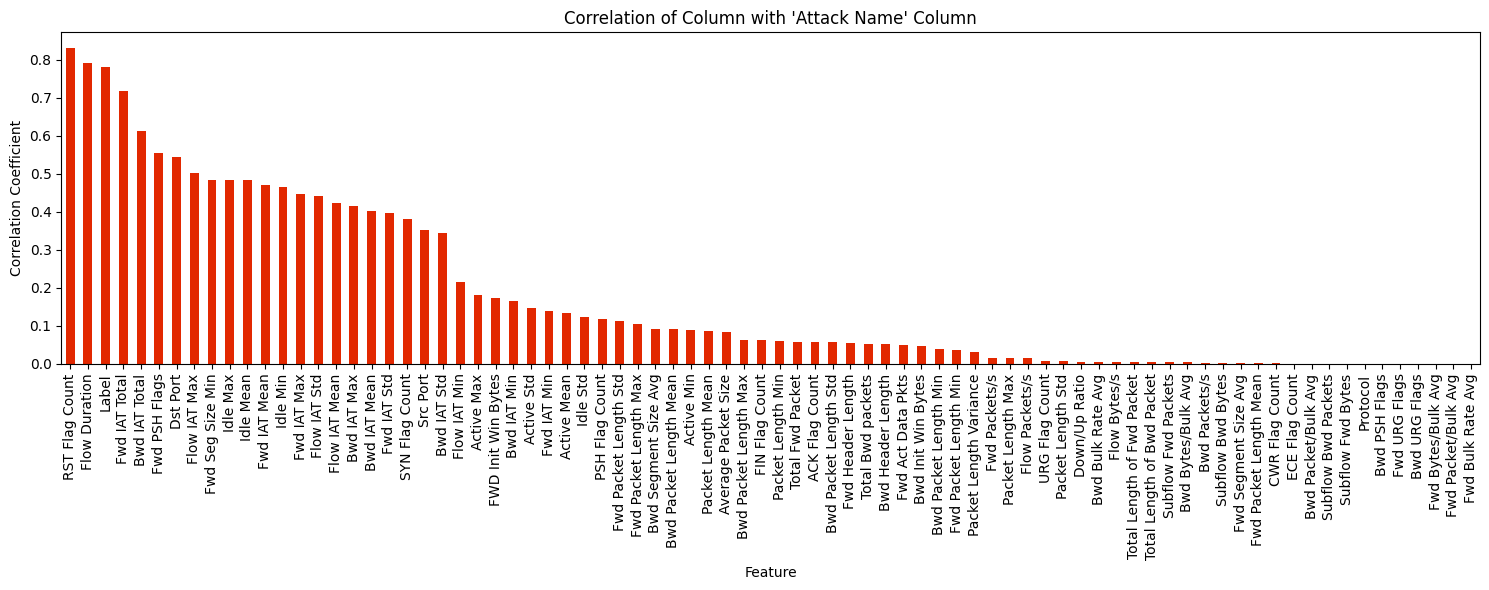

In [7]:


def show_correlation(sample_Data):
  ''' Taking copy of dataset for just showing absolute correlation
    between columns and the 'Attack Name' column.

    Parameters:
    - data: dataset
  '''

  # Taking a copy of data
  data_ = sample_Data.copy()

  # Map attack type labels from strings to numerical codes.
  # This is necessary for machine learning models, which require numerical input.
  # Each attack type is assigned a unique integer value.
  data_['Attack Name'] = data_['Attack Name'].replace({
          'Benign Traffic': 0,
          'DoS Flood': 1 ,
          'Recon Flood': 3 ,
          'MQTT Flood' : 4 ,
          'DDoS Flood' : 2 })

  # Compute correlation matrix.
  corr_matrix = data_.corr()

  # Extract absolute correlation with 'Attack Name' column.
  label_corr = corr_matrix['Attack Name'].drop('Attack Name').abs()

  # Print absolute correlation ratios, sorted from highest to lowest.
  print("\n\n\nAbsolute correlation of each column with the 'Attack Name' column:")
  print(label_corr.sort_values(ascending=False),'\n\n\n\n\n')


  # Plot correlation between features with 'Attack Name' coloumn.
  plt.figure(figsize=(15, 6))
  label_corr.sort_values(ascending=False).plot(kind='bar', color='#e22800')
  plt.title("Correlation of Column with 'Attack Name' Column")
  plt.ylabel("Correlation Coefficient")
  plt.xlabel("Feature")
  plt.tight_layout()
  plt.show()






# Calling for  showing absolute correlation between columns and the 'Attack Name' column.
show_correlation(sample_Data)


# Showing the Pie Chart for Classes Distribution

---



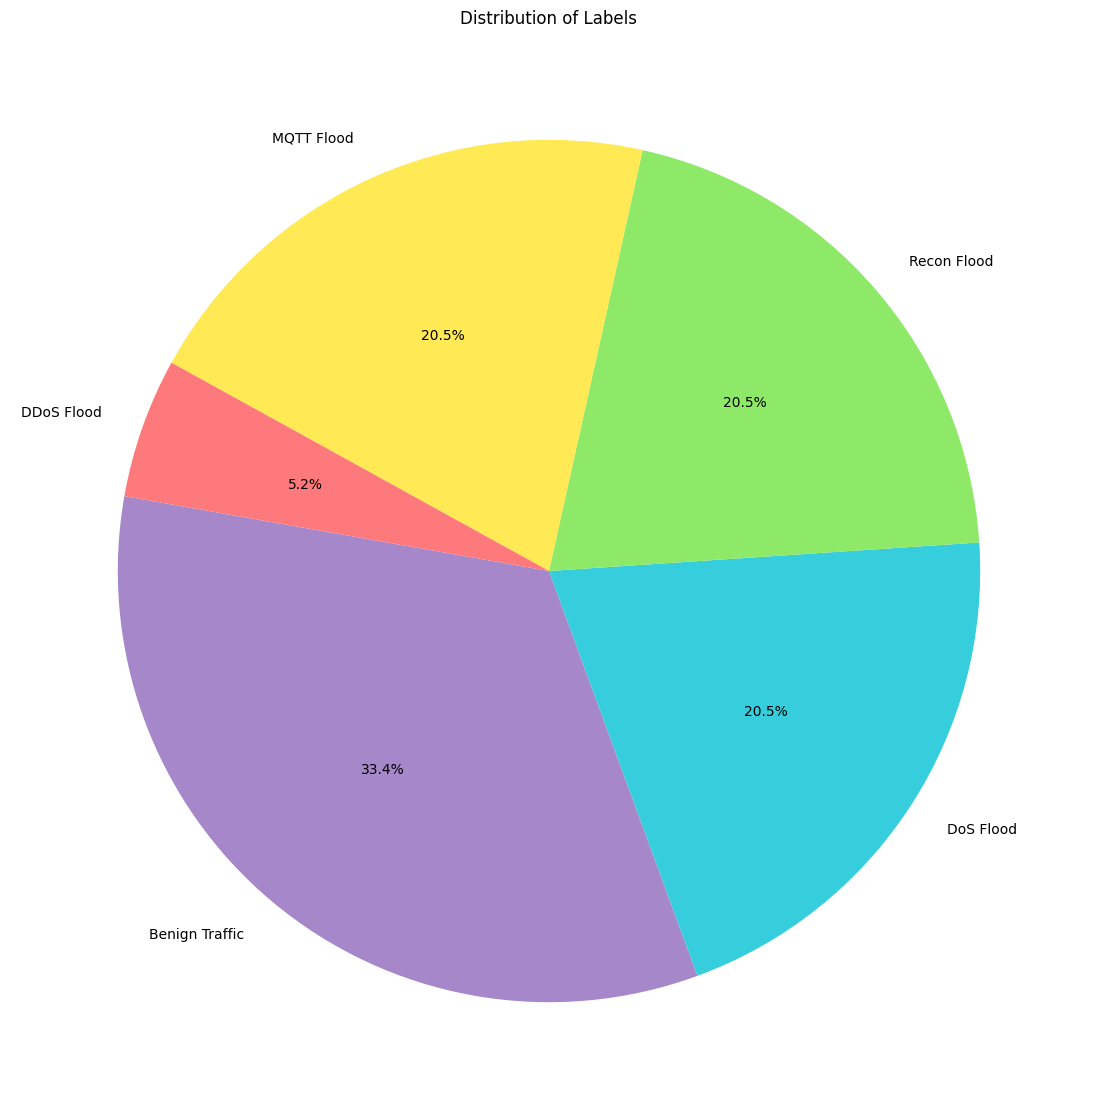

In [8]:

def plot_pie():
  """
  plot pie chart for classes distribution in the dataset.
  """

  label_column = 'Attack Name'

  # Count occurrences of each label
  label_counts = sample_Data[label_column].value_counts()

  # Custom colors for the pie chart
  colors = ['#a587ca', '#36cedc','#8fe968', '#ffea56','#fe797b']

  # Plot the pie chart
  plt.figure(figsize=(14, 14))
  label_counts.plot.pie(autopct='%1.1f%%', startangle=170, colors=colors)
  plt.title("Distribution of Labels")
  plt.ylabel("")  # Remove default y-label for aesthetics
  plt.show()





# Calling for plotting pie chart for classes distribution in the dataset
plot_pie()




# 1- Single Model System for Binary Attack Detection

---



In [9]:

'''Start of Global Variables'''


# Taking a copy of prepared data.
Data = sample_Data.drop(['Attack Name'], axis=1)

# Separate the features (X) from the target labels (y)
# X: All columns except the label
# y: The label column representing the class for each sample
X = Data.drop(columns=['Label'])
y = Data['Label']

# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Standardize features.
# This is important because many models are sensitive to feature scales.
scaler = StandardScaler().set_output(transform="pandas")


# Feature selection by removing low-variance features.
# Features with very low variance may carry little information and can be removed.
# To reduce noise and improve model performance.
var_thresh = VarianceThreshold(
  threshold=0.01
).set_output(transform="pandas")


# Automatically select important features based on a trained Random Forest model.
# Features with importance greater than the mean importance will be kept.
rf_selector = create_feature_selector()


# Build an ensemble model using hard voting from three different classifiers
# Each model votes, and the final prediction is the majority class
voting_model = VotingClassifier([
    ('xgb', XGBClassifier(n_estimators=100,random_state=42)),
    ('lgbm', lgb.LGBMClassifier(n_estimators=100, random_state=42)),
    ('cat', CatBoostClassifier(iterations=100, random_state=42, verbose=0) )
], voting='soft')   # soft = average probabilities


'''End of Global Variables'''






def Single_Model_System(Model, name):
  '''Single model system binary classification
  , with full pipeline.

  Parameters:
  - Model: Classifier model.
  - name: name of model.

  '''

  # Smote process to increase number of training sampels.
  smote = SMOTE(sampling_strategy= { 0:52033 }, random_state=42)


  # Full pipeline with full steps.
  my_pipeline = Pipeline(steps=[
        ('scaler', scaler),
        ('variance_filter', var_thresh),
        ('feature_selector', rf_selector),
        ('smote', smote),
        ('model', Model)
    ])


  # Fit and learn model, and calculate training time of it.
  start = time.time()
  my_pipeline.fit(X_train, y_train)
  end = time.time()
  training_time = end - start
  print(f"\nTraining time of Single-Model-System {name} : {training_time:.4f} seconds.")


  # Prediction the state of traffics by model.
  pred = my_pipeline.predict(X_test)


  if name == "LightGBM Classifier":
    # Calling 'Smote_Analysis' function to view the result of SMOTE onetime.
    Smote_Analysis(X_train, y_train, 0)

    # function to print selected features.
    Features_Selected( X_train , my_pipeline , 'single model' )

    print("\n\n\n")
    #showing pie chart for classes distribution
    plot_pie_chart(X_train, y_train, smote, 'Single Model System')
    print("\n\n\n")


  # Evaluate the model.
  st = "Single Model System " + name
  Evaluation_Printing(X , y , y_test , pred , my_pipeline , st)

  # Plot the confusion matrix
  plot_confusion_matrix_single(
    model= my_pipeline,
    X_test= X_test,
    y_test= y_test,
    class_names= ["Normal", "Attack"],
    title= name
  )


  # Printing Average_Inference_Time to predict by each model.
  Average_Inference_Time( X_test, my_pipeline ,name)





Training time of Single-Model-System LightGBM Classifier : 46.6231 seconds.


SMOTE RESULT: 

Distribution of categories before SMOTE:
Label
1    52033
0    26165
Name: count, dtype: int64

Distribution of categories after SMOTE:
Label
0    52033
1    52033
Name: count, dtype: int64


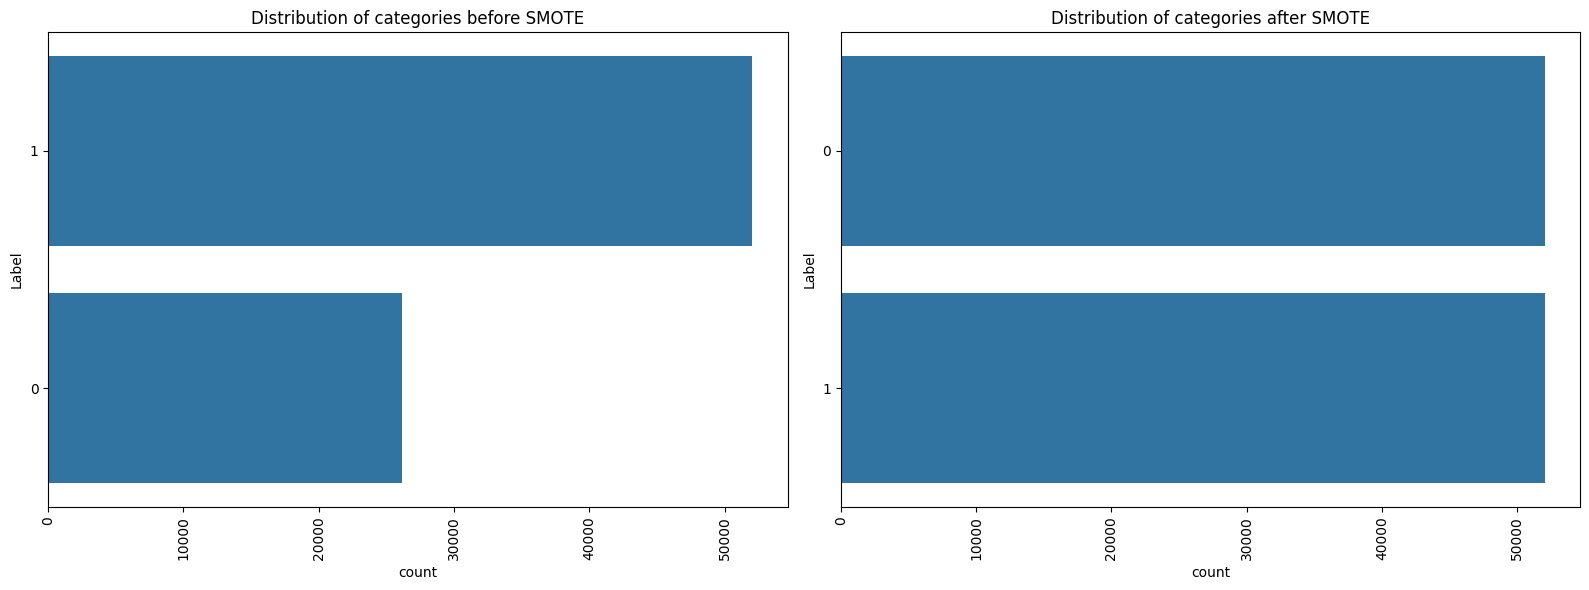






Selected features : 22





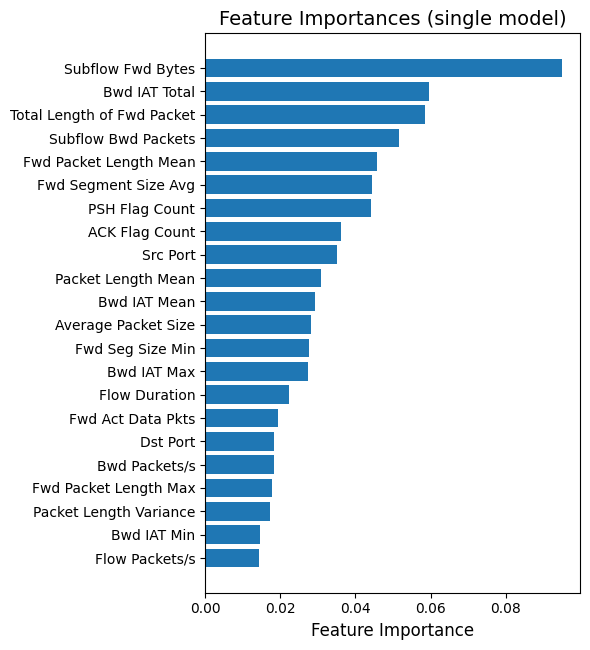

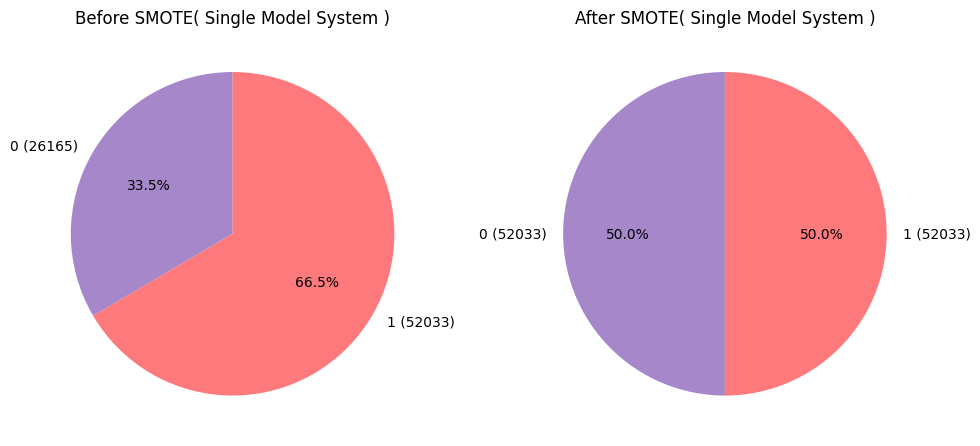








Accuracy of Single Model System LightGBM Classifier : 99.38618925831202 % 


Classification Report for Single Model System LightGBM Classifier:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6455
           1       1.00      0.99      1.00     13095

    accuracy                           0.99     19550
   macro avg       0.99      0.99      0.99     19550
weighted avg       0.99      0.99      0.99     19550



Accuracy by Cross Validation of Single Model System LightGBM Classifier :
 [0.99375959 0.99304348 0.99324808 0.99283851 0.99268505]


A drawing showing the absence of overfitting through cross validation:



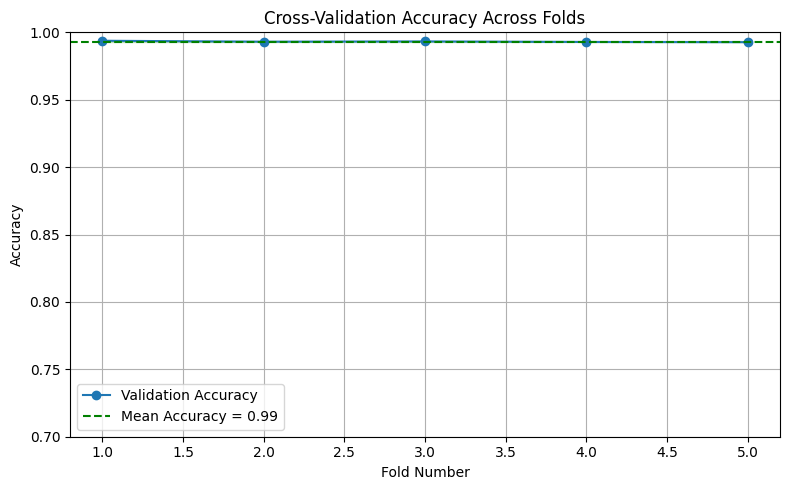

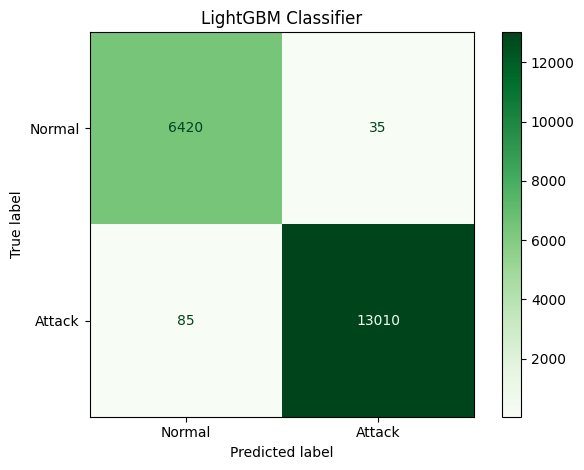







Average inference time per sample LightGBM Classifier (100 samples): 0.061564719676971434 seconds.




In [10]:

# LightGBM Classifier.
Model1 = lgb.LGBMClassifier(verbosity=-1, n_estimators=100, random_state=42)

# Calling single model system with the classifier.
Single_Model_System(Model1, "LightGBM Classifier")



Training time of Single-Model-System CatBoost Classifier : 47.3985 seconds.



Accuracy of Single Model System CatBoost Classifier : 99.23273657289002 % 


Classification Report for Single Model System CatBoost Classifier:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      6455
           1       1.00      0.99      0.99     13095

    accuracy                           0.99     19550
   macro avg       0.99      0.99      0.99     19550
weighted avg       0.99      0.99      0.99     19550



Accuracy by Cross Validation of Single Model System CatBoost Classifier :
 [0.99432225 0.99355499 0.99324808 0.99421965 0.99324774]


A drawing showing the absence of overfitting through cross validation:



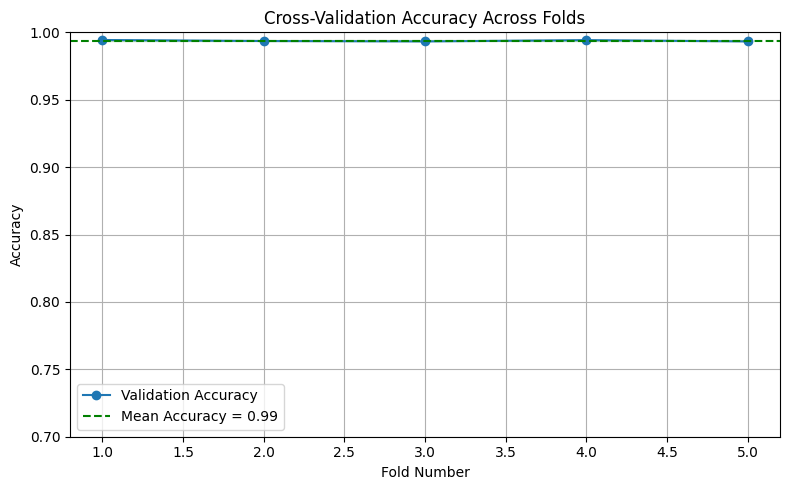

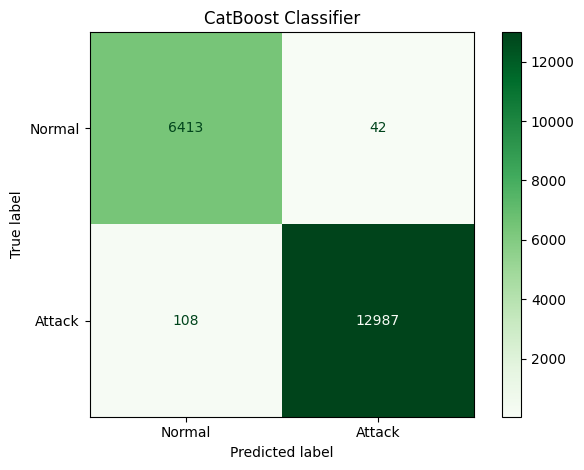







Average inference time per sample CatBoost Classifier (100 samples): 0.06745083093643188 seconds.




In [11]:

# CatBoost Classifier.
Model2 = CatBoostClassifier(iterations=100, random_state=42, verbose=0)   # verbose=0 To stop printing while training.

# Calling single model system with the classifier.
Single_Model_System(Model2, "CatBoost Classifier")



Training time of Single-Model-System XGB Classifier : 46.5144 seconds.



Accuracy of Single Model System XGB Classifier : 99.48849104859335 % 


Classification Report for Single Model System XGB Classifier:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6455
           1       1.00      1.00      1.00     13095

    accuracy                           0.99     19550
   macro avg       0.99      0.99      0.99     19550
weighted avg       0.99      0.99      0.99     19550



Accuracy by Cross Validation of Single Model System XGB Classifier :
 [0.99468031 0.99539642 0.99508951 0.99508926 0.99478234]


A drawing showing the absence of overfitting through cross validation:



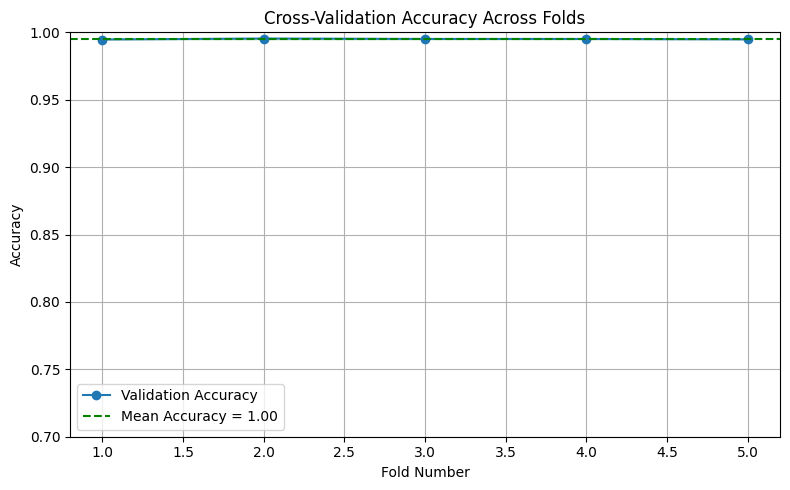

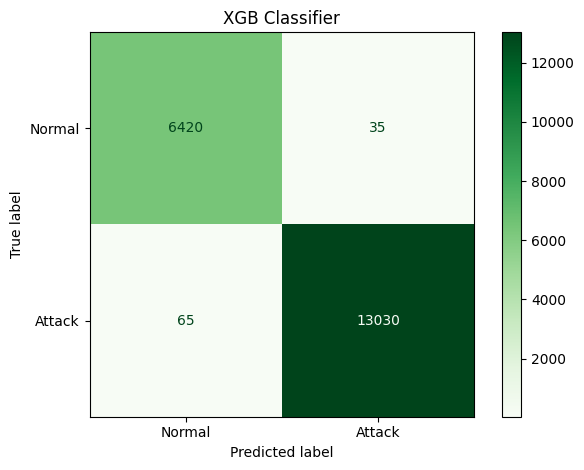







Average inference time per sample XGB Classifier (100 samples): 0.05796596050262451 seconds.




In [12]:

# XGB Classifier.
Model3 = XGBClassifier(n_estimators=100, random_state=42)

# Calling single model system with the classifier.
Single_Model_System(Model3 , "XGB Classifier")


# 2- Layering system With Voting Prediction , Layer 1: Binary Classification. Layer 2: Multi-Class Classification (Attack Name)


---



In [13]:


def prepare_binary_classification_data(data_layer):
  '''Prepare binary classification data.

  Parameters:
  - data_layer: dataset.
  '''

  # New coloumn, to use it in data for determine type of attacks.
  data_layer['attack_type'] = data_layer['Attack Name']

  # New coloumn, to use it in data for determine attack traffic or normal one.
  data_layer['is_attack'] = data_layer['attack_type'].apply(lambda x: 0 if x == 'Benign Traffic' else 1)

  # Map attack type labels from strings to numerical codes.
  # This is necessary for machine learning models, which require numerical input.
  # Each attack type is assigned a unique integer value.
  data_layer['attack_type'] = data_layer['attack_type'].replace({
      'Benign Traffic': 0,
      'DoS Flood': 1,
      'DDoS Flood': 2,
      'Recon Flood': 3,
      'MQTT Flood': 4
  })

  # Splitting the data between the predicted and learned properties (X), and the property we will predict (Y).
  X = data_layer.drop(['Attack Name', 'Label', 'is_attack', 'attack_type'], axis=1)
  y = data_layer['is_attack']

  return X, y, data_layer






def prepare_attack_type_data(data_layer):
  ''' Prepare attack type data.

  Parameters:
  - data_layer: dataset.
  '''

  # Take just data fields for attacks traffic not normal one.
  attack_data = data_layer[data_layer['is_attack'] == 1]

  # Splitting the data between the predicted and learned properties (X), and the property we will predict (Y).
  X = attack_data.drop(['Attack Name', 'Label', 'is_attack', 'attack_type'], axis=1)
  y = attack_data['attack_type']

  return X, y






def train_binary_classifier(X, y):
  ''' Train binary classifier

  Parameters:
  - X: features .
  - y: label, target column.
  '''

  # Split the data into training and testing sets.
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, stratify=y, random_state=42
  )


  # Smote process to increase number of training sampels.
  smote = SMOTE(sampling_strategy={0: 52102}, random_state=42)

  # Calling 'Smote_Analysis' function to view the result of SMOTE.
  Smote_Analysis(X_train , y_train , 3)


  # Full pipeline with full steps.
  model = Pipeline([
      ('scaler', scaler),
      ('variance_filter', var_thresh),
      ('feature_selector', rf_selector),
      ('smote', smote),
      ('ensemble', voting_model)
  ])


  # Fit and learn model, and calculate training time of it.
  start = time.time()
  model.fit(X_train, y_train)
  end = time.time()
  training_time = end - start
  print(f"Training time of Layer 1 (binary class): {training_time:.4f} seconds.")


  # Calling function to print selected features.
  Features_Selected( X_train , model , 'Layer 1' )


  print("\n\n\n")
  #showing pie chart for classes distribution
  plot_pie_chart(X_train, y_train, smote ,'Layer 1')
  print("\n\n\n")


  # Plot the confusion matrix
  plot_confusion_matrix_single(
  model= model,
  X_test= X_test,
  y_test= y_test,
  class_names= ["Normal", "Attack"],
  title= "Binary Classification Confusion Matrix"
  )


  return model, X_test, y_test







def train_attack_type_classifier(X, y):
  ''' Train attack type classifier

  Parameters:
  - X: features .
  - y: label, target column.
  '''

  # Split the data into training and testing sets.
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, stratify=y, random_state=42
  )


  # Smote process to increase number of training sampels.
  smote = SMOTE(sampling_strategy= { 3:3270 , 4:3270 , 2:1500 }, random_state=42)

  # Calling 'Smote_Analysis' function to view the result of SMOTE.
  Smote_Analysis(X_train , y_train , 1)


  # Full pipeline with full steps.
  model = Pipeline([
      ('scaler', scaler),
      ('variance_filter', var_thresh),
      ('feature_selector', rf_selector),
      ('smote', smote),
      ('ensemble', voting_model)
  ])


  # Fit and learn model, and calculate training time of it.
  start = time.time()
  model.fit(X_train, y_train)
  end = time.time()
  training_time = end - start
  print(f"Training time of Layer 2 (multiclass): {training_time:.4f} seconds.")


  # Calling function to print selected features.
  Features_Selected( X_train , model , 'Layer 2' )


  print("\n\n\n")
  #showing pie chart for classes distribution
  plot_pie_chart(X_train, y_train, smote, 'Layer 2')
  print("\n\n\n")


  # Class names exist
  class_names = ['DoS Flood', 'DDoS Flood', 'Recon Flood', 'MQTT Flood']


  # Plot confusion matrix
  plot_confusion_matrix_voting(
  model= model,
  model_name= "Voting Classifier",
  X_test= X_test,
  y_test= y_test,
  class_names= class_names,
  lab = [1,2,3,4],
  title= "Multi class Classification Confusion Matrix"
  )


  return model, X_test, y_test







/tmp/ipykernel_10990/2628233868.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_layer['attack_type'] = data_layer['attack_type'].replace({




SMOTE RESULT: 

Distribution of categories before SMOTE:
is_attack
1    52102
0    26096
Name: count, dtype: int64

Distribution of categories after SMOTE:
is_attack
1    52102
0    52102
Name: count, dtype: int64


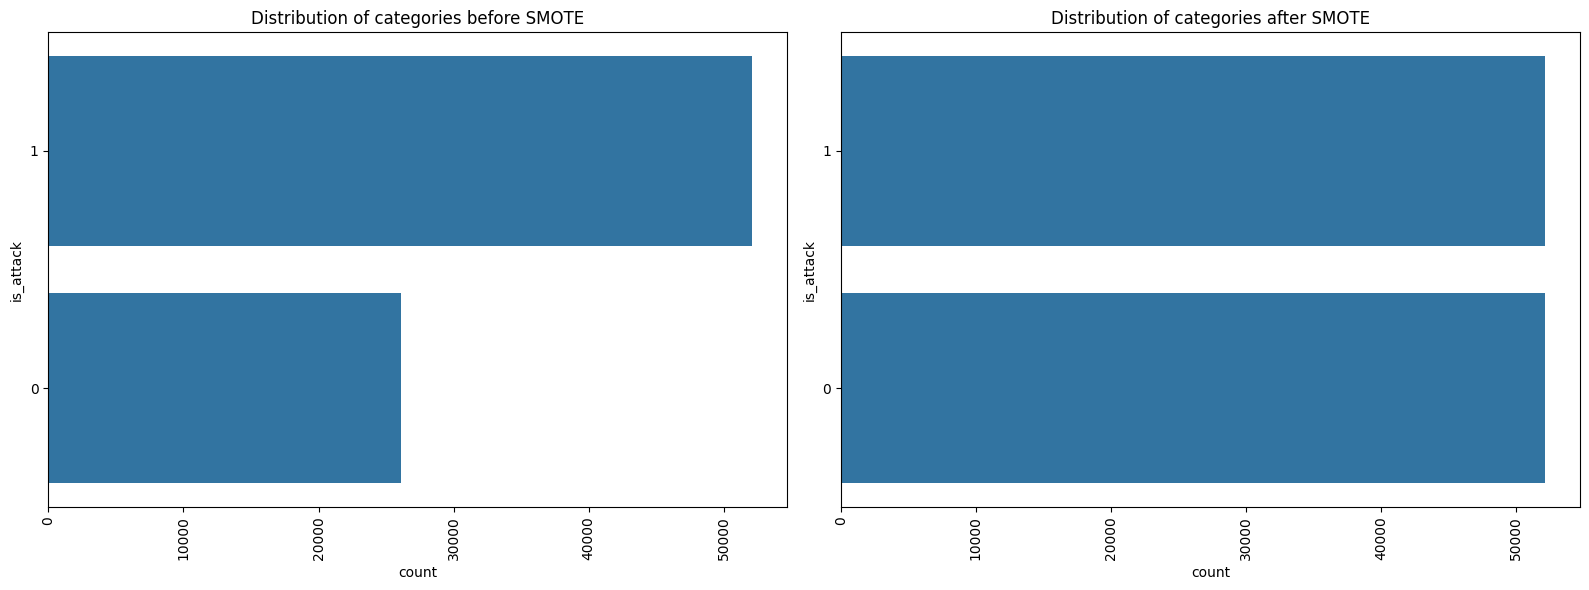





Training time of Layer 1 (binary class): 52.4985 seconds.

Selected features : 23





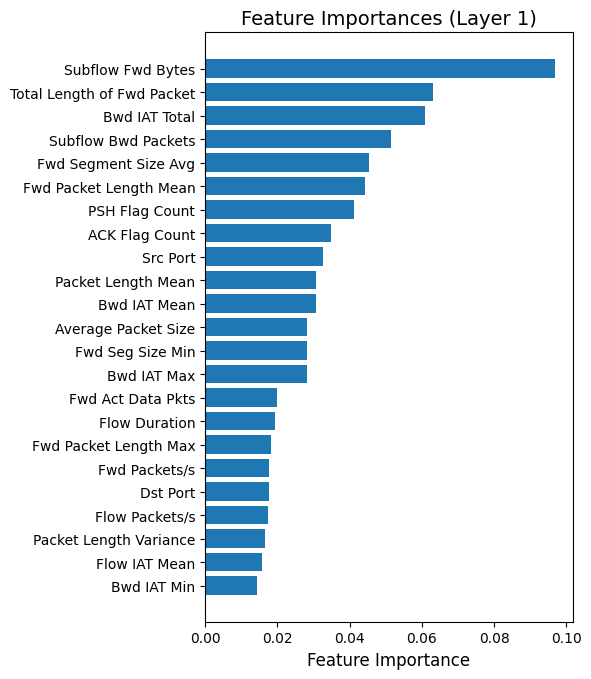

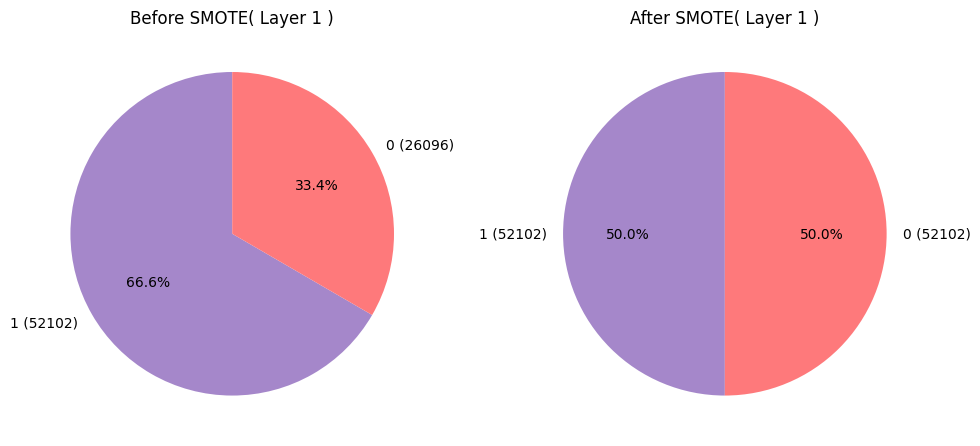

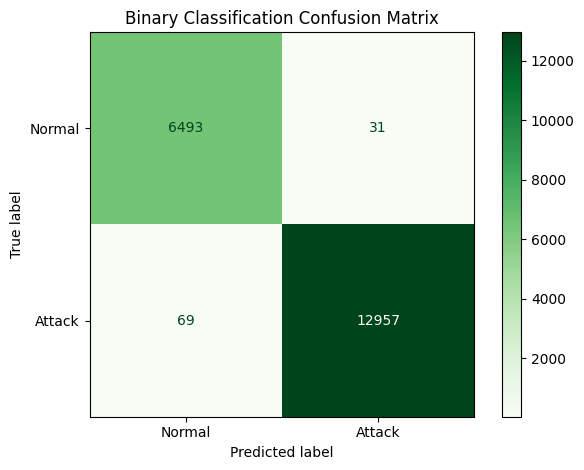








Accuracy of Layer 1: Binary Classification (Layering) : 99.48849104859335 % 


Classification Report for Layer 1: Binary Classification (Layering):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      6524
           1       1.00      0.99      1.00     13026

    accuracy                           0.99     19550
   macro avg       0.99      0.99      0.99     19550
weighted avg       0.99      0.99      0.99     19550



Accuracy by Cross Validation of Layer 1: Binary Classification (Layering) :
 [0.99519182 0.9941688  0.99514066 0.99427081 0.99411735]


A drawing showing the absence of overfitting through cross validation:



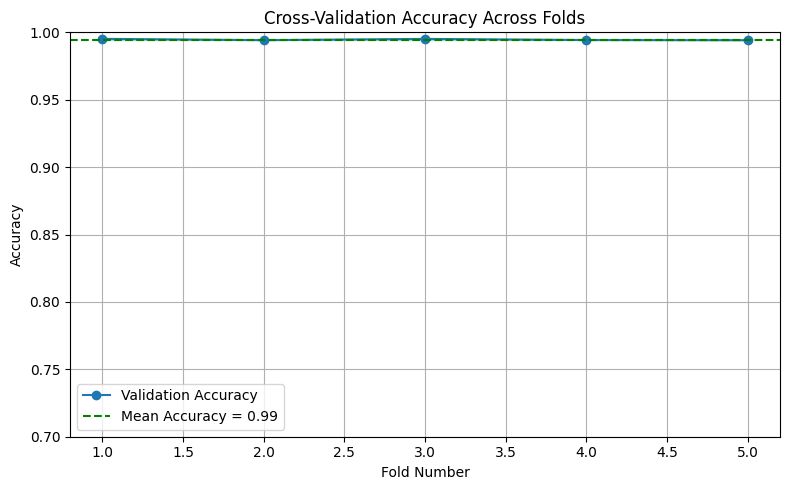



Average inference time per sample Layer_1 (100 samples): 0.0676620888710022 seconds.




In [14]:


'''Layering & Voting System , Layer 1: Binary Classification
Layer 2: Multi-Class Classification (Attack Name).'''

# Taking a copy of prepared data.
data_layer = sample_Data.copy()

# 1. Binary classification data processing and preparing .
X_binary, y_binary, df_processed = prepare_binary_classification_data(data_layer)

# 2. Training a binary classification model.
binary_model, X_test_binary, y_test_binary = train_binary_classifier(X_binary, y_binary)

# 3. Prediction by model one.
y_pred_binary = binary_model.predict(X_test_binary)

# Evaluate the model.
Evaluation_Printing(X_binary, y_binary , y_test_binary , y_pred_binary , binary_model,
        "Layer 1: Binary Classification (Layering)"
    )

# Printing Average_Inference_Time to predict by model.
Average_Inference_Time(X_test_binary , binary_model ,"Layer_1")





SMOTE RESULT: 

Distribution of categories before SMOTE:
attack_type
1    3270
4    3176
3    3143
2     776
Name: count, dtype: int64

Distribution of categories after SMOTE:
attack_type
1    3270
4    3270
3    3270
2    1500
Name: count, dtype: int64


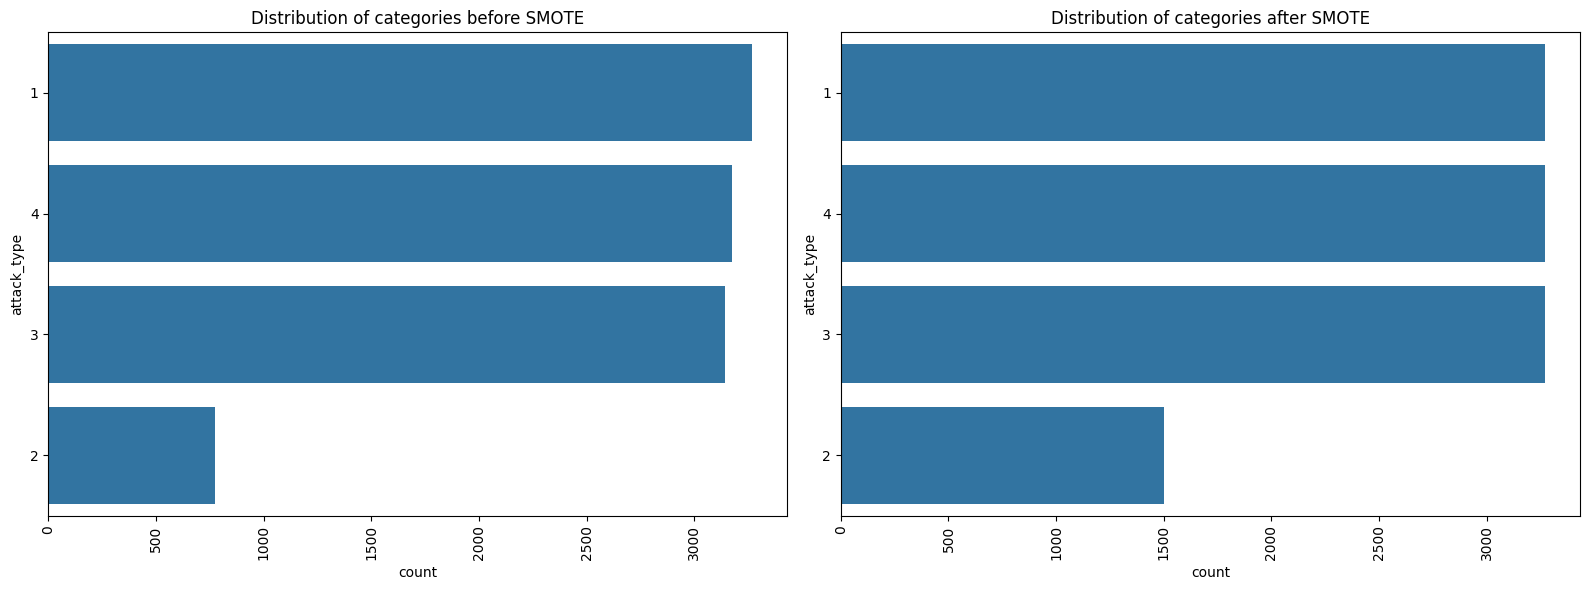





Training time of Layer 2 (multiclass): 6.6745 seconds.

Selected features : 17





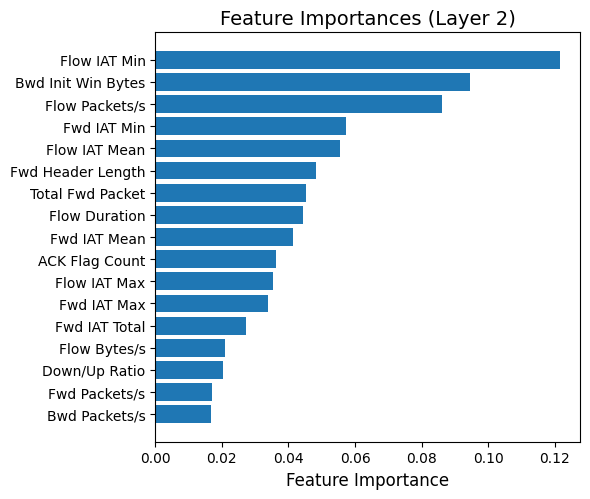

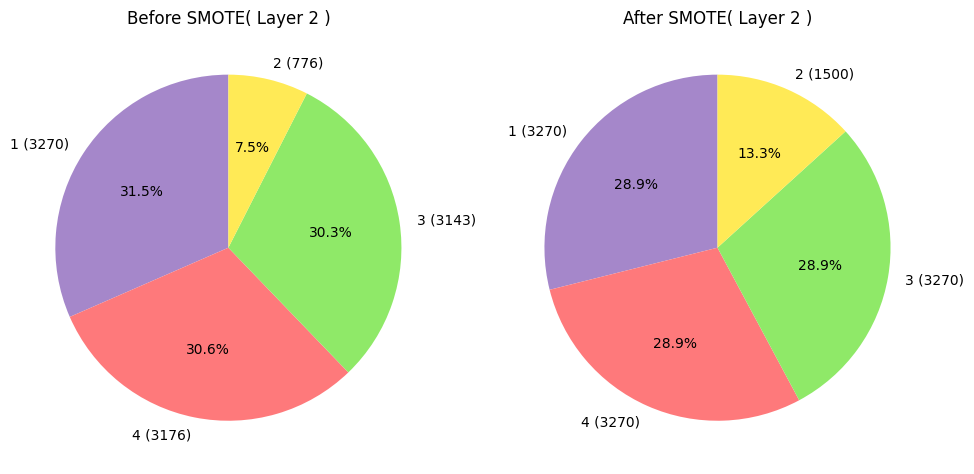

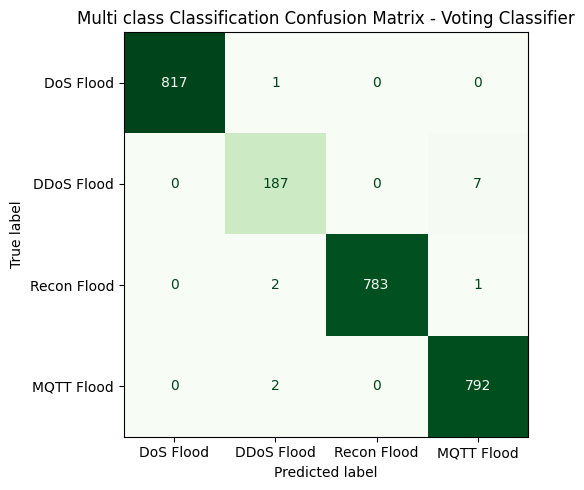








Accuracy of Layer 2: Multi-Class Classification (Layering) : 99.49845679012346 % 


Classification Report for Layer 2: Multi-Class Classification (Layering):
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       818
           2       0.97      0.96      0.97       194
           3       1.00      1.00      1.00       786
           4       0.99      1.00      0.99       794

    accuracy                           0.99      2592
   macro avg       0.99      0.99      0.99      2592
weighted avg       0.99      0.99      0.99      2592



Accuracy by Cross Validation of Layer 2: Multi-Class Classification (Layering) :
 [0.99768519 0.99537037 0.99421073 0.99536858 0.99652644]


A drawing showing the absence of overfitting through cross validation:



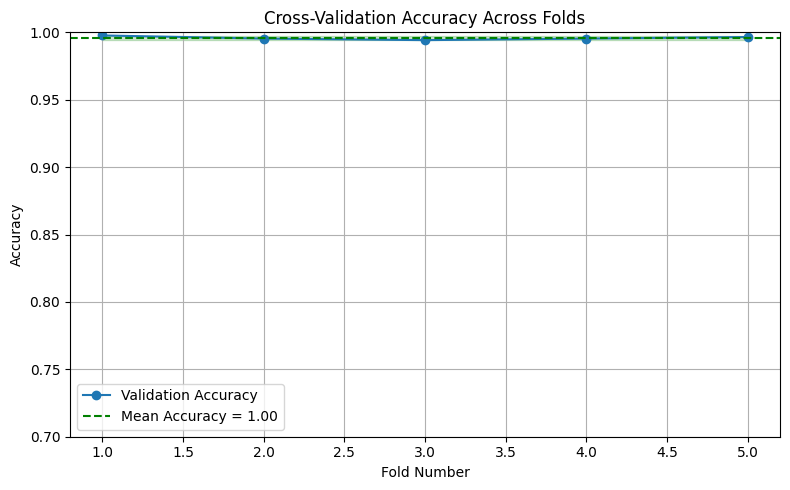



Average inference time per sample Layer_2 (100 samples): 0.042049181461334226 seconds.




In [15]:


# Taking a copy of previouse predictions.
pred_attack = y_pred_binary

# Extract only the samples that were predicted as attacks (predicted == 1)
# Use their indices to select the corresponding rows from the full processed DataFrame
df_attacks = df_processed.loc[X_test_binary[pred_attack == 1].index]

# 5. Preparing attack classification data.
X_attack, y_attack = prepare_attack_type_data(df_attacks)

# 6. Training an attack type classification model.
attack_model, X_test2, y_test2 = train_attack_type_classifier(X_attack, y_attack)

# 7. Prediction by model two.
final_pred_attack = attack_model.predict(X_test2)

# Evaluate the model.
Evaluation_Printing(X_attack, y_attack , y_test2 , final_pred_attack , attack_model ,
                        "Layer 2: Multi-Class Classification (Layering)")

# Printing Average_Inference_Time to predict by model.
Average_Inference_Time(X_test2 , attack_model ,"Layer_2")



# 3- Without Layering System, With Voting Prediction



---



/tmp/ipykernel_10990/693955757.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  complete_Data['Attack Name'] = complete_Data['Attack Name'].replace({




SMOTE RESULT: 

Distribution of categories before SMOTE:
Attack Name
0    26165
4    16017
1    16008
3    15925
2     4083
Name: count, dtype: int64

Distribution of categories after SMOTE:
Attack Name
0    26165
1    26165
3    26165
4    26165
2     8150
Name: count, dtype: int64


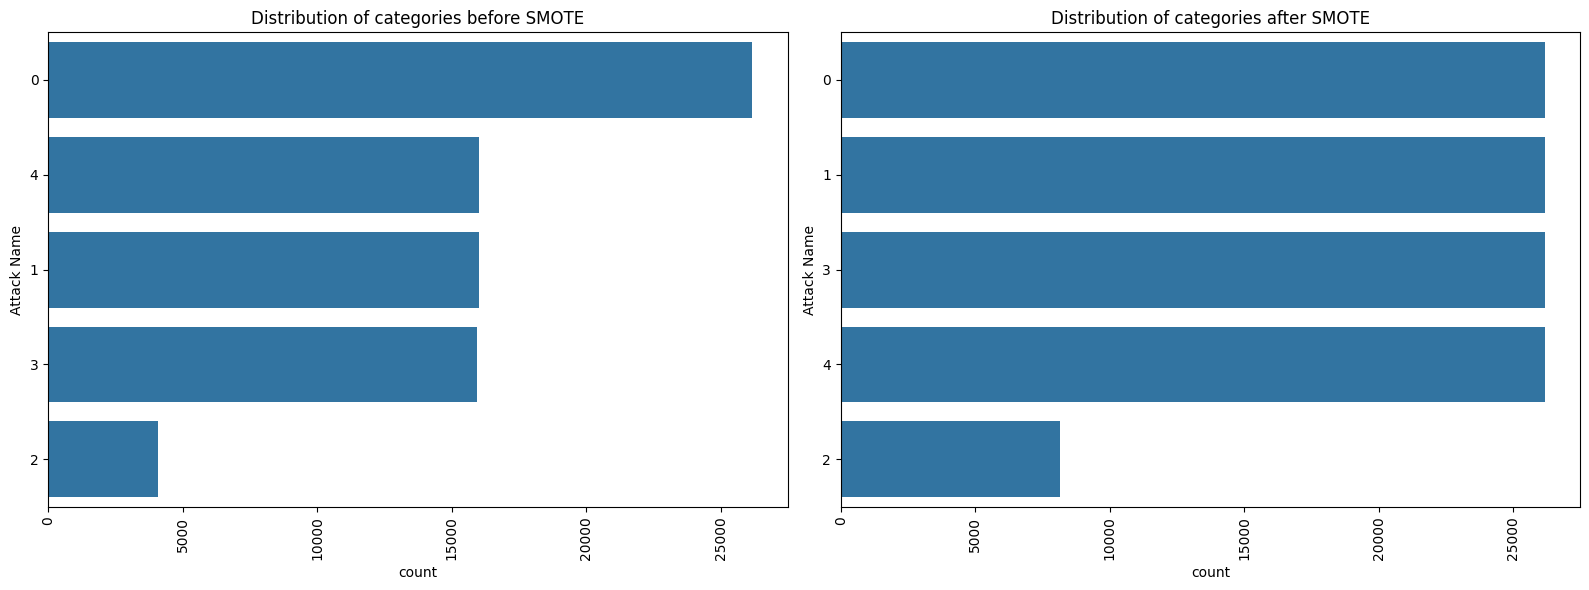






Training time (No Layering + RF Selection): 78.1226 seconds.

Selected features : 27





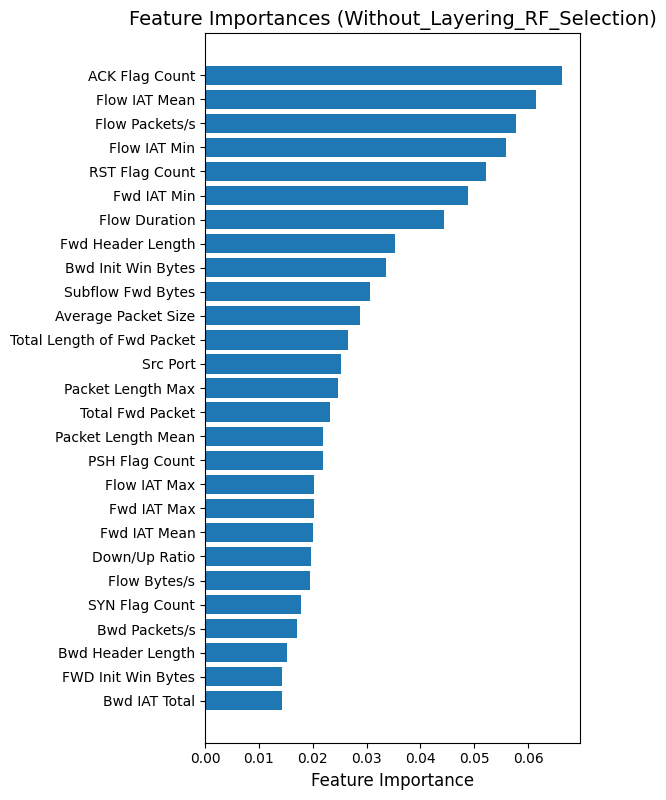

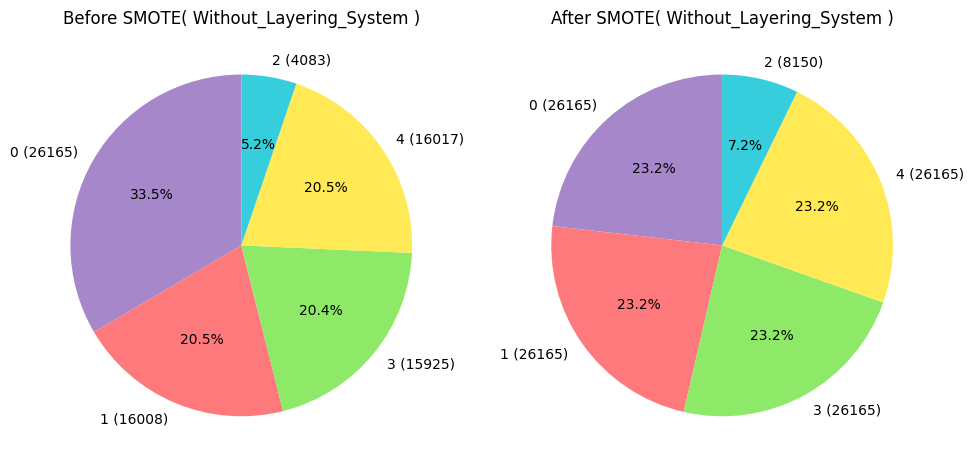

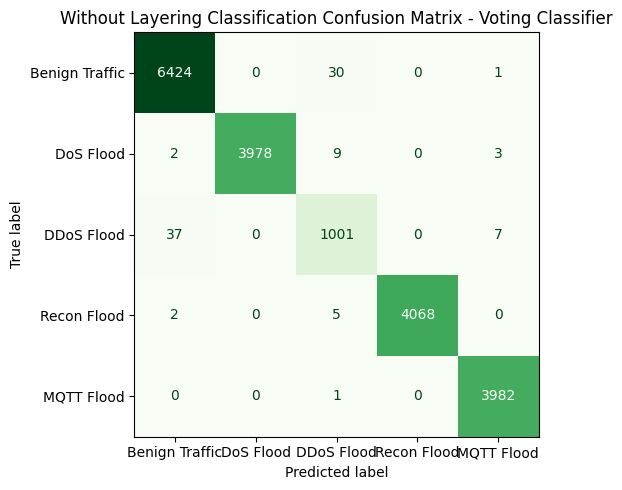








Accuracy of No Layering RF Selection Voting : 99.50383631713555 % 


Classification Report for No Layering RF Selection Voting:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      6455
           1       1.00      1.00      1.00      3992
           2       0.96      0.96      0.96      1045
           3       1.00      1.00      1.00      4075
           4       1.00      1.00      1.00      3983

    accuracy                           1.00     19550
   macro avg       0.99      0.99      0.99     19550
weighted avg       1.00      1.00      1.00     19550



Accuracy by Cross Validation of No Layering RF Selection Voting :
 [0.99350384 0.99473146 0.99370844 0.99360581 0.99478234]


A drawing showing the absence of overfitting through cross validation:



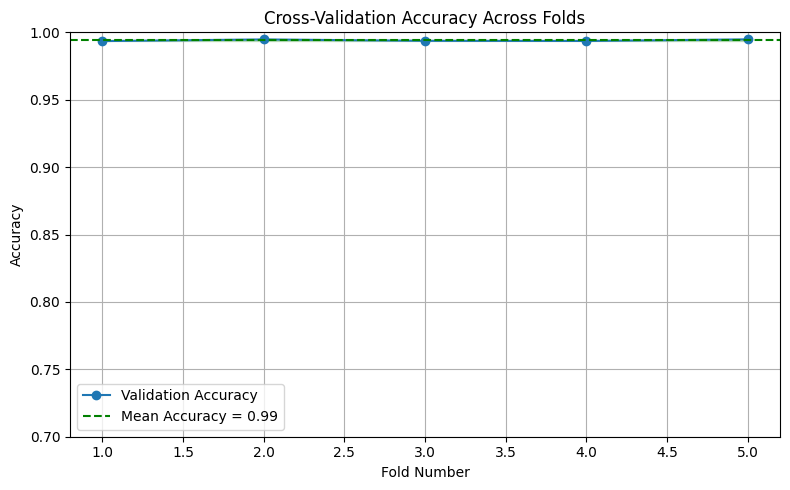



Average inference time per sample (Without Layering) (100 samples): 0.07200290441513062 seconds.




In [16]:


def without_layering_system():
  ''' Multi-Class Classification System,
  all classes in one layer, without layering.

  '''

  # Taking a copy of prepared data.
  complete_Data = sample_Data.copy()

  # Map attack type labels from strings to numerical codes.
  # This is necessary for machine learning models, which require numerical input.
  # Each attack type is assigned a unique integer value.
  complete_Data['Attack Name'] = complete_Data['Attack Name'].replace({
          'Benign Traffic': 0,
          'DoS Flood': 1,
          'Recon Flood': 3,
          'MQTT Flood': 4,
          'DDoS Flood': 2
      })


  # Separate the features (X complete) from the target labels (y complete)
  # X complete: All columns except the label
  # y complete: The label column representing the class for each sample
  X_complete = complete_Data.drop(columns=["Label", "Attack Name"])
  y_complete = complete_Data["Attack Name"]

  # Split the data into training and testing sets.
  X_train2, X_test2, y_train2, y_test2 = train_test_split(
          X_complete, y_complete, test_size=0.2, random_state=42
      )


  # Smote process to increase number of training sampels.
  smote = SMOTE(sampling_strategy= {1:26165, 3:26165, 4:26165, 2: 8150 }, random_state=42)

  # Calling 'Smote_Analysis' function to view the result of SMOTE.
  Smote_Analysis( X_train2 , y_train2 , 2 )


  # Full pipeline with full steps.
  ensemble_pipeline = Pipeline([
          ('scaler', scaler),
          ('variance_filter', var_thresh),
          ('feature_selector', rf_selector),
          ('smote', smote),
          ('ensemble', voting_model)
      ])


  # Fit and learn model, and calculate training time of it.
  start = time.time()
  ensemble_pipeline.fit(X_train2 , y_train2)
  end = time.time()
  training_time = end - start
  print(f"\nTraining time (No Layering + RF Selection): {training_time:.4f} seconds.")


  # Calling function to print selected features.
  Features_Selected( X_train2 , ensemble_pipeline , 'Without_Layering_RF_Selection' )


  print("\n\n\n")
  #showing pie chart for classes distribution
  plot_pie_chart(X_train2, y_train2, smote,'Without_Layering_System')
  print("\n\n\n")


  # Class names exist
  class_names = ['Benign Traffic','DoS Flood', 'DDoS Flood', 'Recon Flood', 'MQTT Flood']

  # Plot confusion matrix
  plot_confusion_matrix_voting(
  model= ensemble_pipeline,
  model_name= "Voting Classifier",
  X_test= X_test2,
  y_test= y_test2,
  class_names= class_names,
  lab = [0,1,2,3,4],
  title= "Without Layering Classification Confusion Matrix"
  )


  # Prediction by model.
  preds = ensemble_pipeline.predict(X_test2)


  # Evaluate the model.
  Evaluation_Printing(X_complete, y_complete, y_test2, preds,
                          ensemble_pipeline, "No Layering RF Selection Voting")


  # Printing Average_Inference_Time to predict by model.
  Average_Inference_Time(X_test2 , ensemble_pipeline, "(Without Layering)")








# Caliing system number three, which without layering system.
without_layering_system()


